In [1]:
# VISIOASSIST Depth Anything

In [2]:
import torch

print(torch.cuda.is_available())

True


In [3]:
!pip install transformers accelerate -q
!pip install opencv-python-headless matplotlib pillow -q

In [4]:
# Cargar Depth Anything V2 small
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

depth_pipe = pipeline(
    task = "depth-estimation",
    model = "depth-anything/Depth-Anything-V2-Small-hf",
    device = device,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

The image processor of type `DPTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [5]:
# Funcion de estimacion profundidad
import cv2
import numpy as np
from PIL import Image

def estimar_profundidad(frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(frame_rgb)
    resultado = depth_pipe(pil_img)
    depth_np = np.array(resultado["depth"], dtype=np.float32)
    depth_norm = cv2.normalize(depth_np, None, 0, 255, cv2.NORM_MINMAX)
    return depth_norm.astype(np.uint8)

Saving salida01_00541.jpg to salida01_00541.jpg


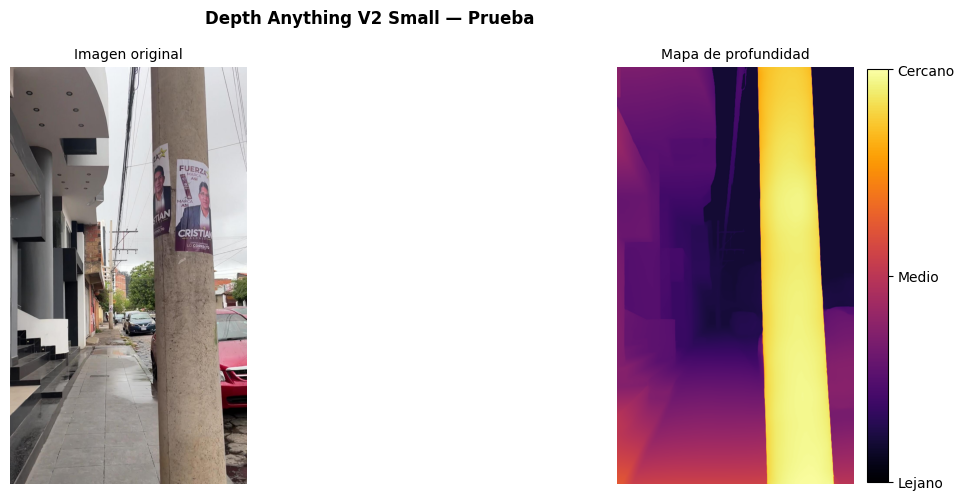

In [10]:
# Probar con una imagen
import matplotlib.pyplot as plt
from google.colab import files

# subir una imagen de prueba
uploaded = files.upload()

nombre = list(uploaded.keys())[0]
frame = cv2.imread(nombre)
mapa = estimar_profundidad(frame)
coloreado = cv2.applyColorMap(mapa, cv2.COLORMAP_INFERNO)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Depth Anything V2 Small — Prueba", fontsize=12, fontweight="bold")

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen original", fontsize=10)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(coloreado, cv2.COLOR_BGR2RGB))
axes[1].set_title("Mapa de profundidad", fontsize=10)
axes[1].axis("off")

sm   = plt.cm.ScalarMappable(cmap="inferno", norm=plt.Normalize(0, 255))
cbar = plt.colorbar(sm, ax=axes[1], fraction=0.03, pad=0.02)
cbar.set_ticks([0, 127, 255])
cbar.set_ticklabels(["Lejano", "Medio", "Cercano"])

plt.tight_layout()
plt.savefig("depth_prueba.png", dpi=130, bbox_inches="tight")
plt.show()

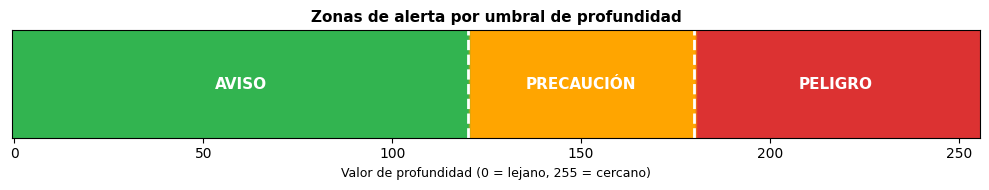

PELIGRO: valor > 180
PRECAUCIÓN: valor entre 120 y 180
AVISO: valor < 120


In [11]:
# Calibracion de umbrales
import matplotlib.patches as patches

UMBRAL_PELIGRO = 180
UMBRAL_PRECAUCION = 120

def clasificar_proximidad(valor):
    if valor > UMBRAL_PELIGRO:
        return "PELIGRO"
    elif valor > UMBRAL_PRECAUCION:
        return "PRECAUCION"
    else:
        return "AVISO"

zonas = np.zeros((100, 256, 3), dtype=np.uint8)
for x in range(256):
    if x > UMBRAL_PELIGRO:
        zonas[:, x] = [220, 50, 50]
    elif x > UMBRAL_PRECAUCION:
        zonas[:, x] = [255, 165, 0]
    else:
        zonas[:, x] = [50, 180, 80]

fig, ax = plt.subplots(figsize=(10, 2))
ax.imshow(zonas, aspect="auto")
ax.axvline(UMBRAL_PRECAUCION, color="white", linewidth=2, linestyle="--")
ax.axvline(UMBRAL_PELIGRO, color="white", linewidth=2, linestyle="--")
ax.text(UMBRAL_PRECAUCION / 2, 50, "AVISO", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.text((UMBRAL_PRECAUCION + UMBRAL_PELIGRO) / 2, 50, "PRECAUCIÓN", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.text((UMBRAL_PELIGRO + 255) / 2, 50, "PELIGRO", ha="center", va="center", color="white", fontsize=11, fontweight="bold")
ax.set_xlabel("Valor de profundidad (0 = lejano, 255 = cercano)", fontsize=9)
ax.set_yticks([])
ax.set_title("Zonas de alerta por umbral de profundidad", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("umbrales_profundidad.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"PELIGRO: valor > {UMBRAL_PELIGRO}")
print(f"PRECAUCIÓN: valor entre {UMBRAL_PRECAUCION} y {UMBRAL_PELIGRO}")
print(f"AVISO: valor < {UMBRAL_PRECAUCION}")

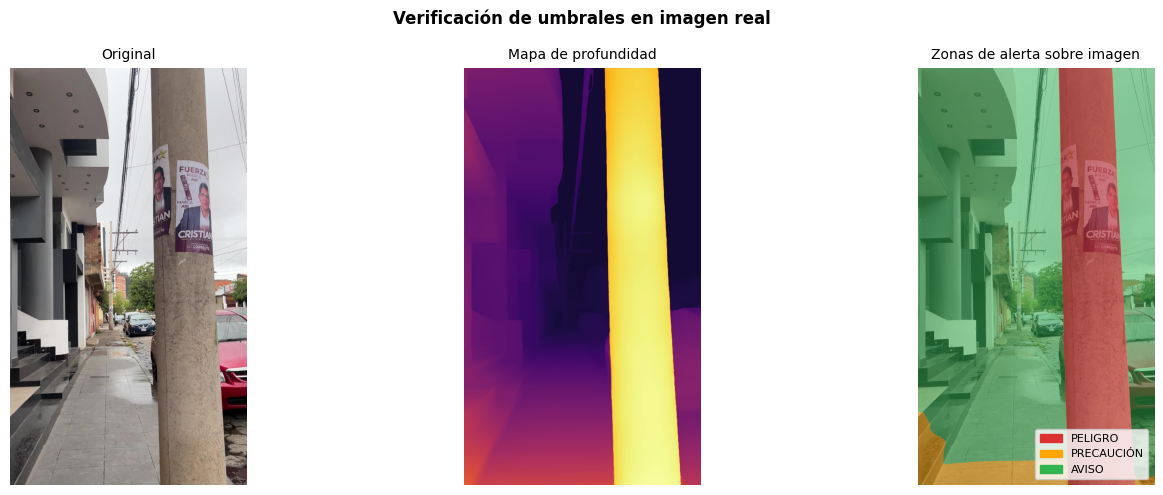


Distribución de zonas en la imagen:
PELIGRO : 25.2% del frame
PRECAUCIÓN : 4.9% del frame
AVISO : 70.0% del frame


In [12]:
# Verificar umbrales en la imagen de prueba

mascara_peligro = (mapa > UMBRAL_PELIGRO).astype(np.uint8) * 255
mascara_precaucion = ((mapa > UMBRAL_PRECAUCION) & (mapa <= UMBRAL_PELIGRO)).astype(np.uint8) * 255
mascara_aviso = (mapa <= UMBRAL_PRECAUCION).astype(np.uint8) * 255

overlay = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB).copy()
overlay[mascara_peligro > 0] = (overlay[mascara_peligro > 0] * 0.5 + np.array([220,  50,  50]) * 0.5).astype(np.uint8)
overlay[mascara_precaucion > 0] = (overlay[mascara_precaucion > 0] * 0.5 + np.array([255, 165, 0]) * 0.5).astype(np.uint8)
overlay[mascara_aviso > 0] = (overlay[mascara_aviso > 0] * 0.5 + np.array([ 50, 180,  80]) * 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Verificación de umbrales en imagen real", fontsize=12, fontweight="bold")

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original", fontsize=10)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(coloreado, cv2.COLOR_BGR2RGB))
axes[1].set_title("Mapa de profundidad", fontsize=10)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Zonas de alerta sobre imagen", fontsize=10)
axes[2].axis("off")

leyenda = [
    patches.Patch(color=(220/255, 50/255, 50/255), label="PELIGRO"),
    patches.Patch(color=(255/255, 165/255, 0/255), label="PRECAUCIÓN"),
    patches.Patch(color=(50/255, 180/255, 80/255), label="AVISO"),
]
axes[2].legend(handles=leyenda, loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("depth_zonas.png", dpi=130, bbox_inches="tight")
plt.show()

pct_peligro    = (mascara_peligro    > 0).mean() * 100
pct_precaucion = (mascara_precaucion > 0).mean() * 100
pct_aviso      = (mascara_aviso      > 0).mean() * 100

print(f"\nDistribución de zonas en la imagen:")
print(f"PELIGRO : {pct_peligro:.1f}% del frame")
print(f"PRECAUCIÓN : {pct_precaucion:.1f}% del frame")
print(f"AVISO : {pct_aviso:.1f}% del frame")

In [13]:
# Descargar resultados
from google.colab import files

files.download("depth_prueba.png")
files.download("depth_zonas.png")
files.download("umbrales_profundidad.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>